<a href="https://colab.research.google.com/github/fideliseshun/DSRP-Research-Project/blob/main/DSRP_Research_Project_Messi_vs_Ronaldo_FIFA_World_Cup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Research Project - Messi vs Ronaldo FIFA World Cup Goat Debate**

**1. Importing Libraries, functions, and dataset**


In [ ]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
# Import dataset
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Ronaldo%20V.s.%20Messi/cleaned_goat_world_cup_data_level1.csv"
WorldCup_df = pd.read_csv(url)

In [ ]:
# Adding data from 2026 FIFA World Cup - Adding rows

new_rows_data = [
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-21',
        'match_name': 'Portugal vs DR Congo',
        'match_date': '2026-06-17',
        'stage_name': 'group stage',
        'group_name': 'Group K',
        'team_name': 'Portugal',
        'player_id': 'P-70442',
        'given_name': 'Cristiano',
        'family_name': 'Ronaldo',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 0,
        'open_play_goals': 0,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 0,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-47',
        'match_name': 'Uzbekistan vs Portugal',
        'match_date': '2026-06-23',
        'stage_name': 'group stage',
        'group_name': 'Group K',
        'team_name': 'Portugal',
        'player_id': 'P-70442',
        'given_name': 'Cristiano',
        'family_name': 'Ronaldo',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 2,
        'open_play_goals': 2,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 0,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-71',
        'match_name': 'Portugal vs Columbia',
        'match_date': '2026-06-27',
        'stage_name': 'group stage',
        'group_name': 'Group K',
        'team_name': 'Portugal',
        'player_id': 'P-70442',
        'given_name': 'Cristiano',
        'family_name': 'Ronaldo',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 0,
        'open_play_goals': 0,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 0,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-83',
        'match_name': 'Portugal vs Croatia',
        'match_date': '2026-07-02',
        'stage_name': 'round of 32',
        'group_name': 'not applicable',
        'team_name': 'Portugal',
        'player_id': 'P-70442',
        'given_name': 'Cristiano',
        'family_name': 'Ronaldo',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 81,
        'total_goals': 1,
        'open_play_goals': 1,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-93',
        'match_name': 'Spain vs Portugal',
        'match_date': '2026-07-06',
        'stage_name': 'round of 16',
        'group_name': 'not applicable',
        'team_name': 'Portugal',
        'player_id': 'P-70442',
        'given_name': 'Cristiano',
        'family_name': 'Ronaldo',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 0,
        'open_play_goals': 0,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-19',
        'match_name': 'Argentina vs Algeria',
        'match_date': '2026-06-16',
        'stage_name': 'group stage',
        'group_name': 'Group J',
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 80,
        'total_goals': 3,
        'open_play_goals': 3,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 0,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-43',
        'match_name': 'Austria vs Argentina',
        'match_date': '2026-06-22',
        'stage_name': 'group stage',
        'group_name': 'Group J',
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 2,
        'open_play_goals': 2,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 0,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-72',
        'match_name': 'Argentina vs Jordan',
        'match_date': '2026-06-27',
        'stage_name': 'group stage',
        'group_name': 'Group J',
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 0,
        'substitute': 1,
        'minutes_played': 31,
        'total_goals': 1,
        'open_play_goals': 1,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 0,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-86',
        'match_name': 'Argentina vs Cape Verde',
        'match_date': '2026-07-03',
        'stage_name': 'round of 32',
        'group_name': 'not applicable',
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 120,
        'total_goals': 1,
        'open_play_goals': 1,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-95',
        'match_name': 'Argentina vs Egypt',
        'match_date': '2026-07-07',
        'stage_name': 'round of 16',
        'group_name': 'not applicable',
        'team_name': 'Argentina',
        'player_id': 'P-14578',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 1,
        'open_play_goals': 1,
        'penalty_goals': 0,
        'assists': 1,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-100',
        'match_name': 'Switzerland vs Argentina',
        'match_date': '2026-07-11',
        'stage_name': 'quarter-finals',
        'group_name': "not applicable",
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 120,
        'total_goals': 0,
        'open_play_goals': 0,
        'penalty_goals': 0,
        'assists': 1,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-102',
        'match_name': 'Argentina vs England',
        'match_date': '2026-07-15',
        'stage_name': 'semi-finals',
        'group_name': 'not applicable',
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 90,
        'total_goals': 0,
        'open_play_goals': 0,
        'penalty_goals': 0,
        'assists': 2,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    },
    {
        'tournament_id': 'WC-2026',
        'tournament_name': "2026 FIFA Men's World Cup",
        'match_id': 'M-2026-104',
        'match_name': 'Spain vs Argentina',
        'match_date': '2026-07-19',
        'stage_name': 'final',
        'group_name': 'not applicable',
        'team_name': 'Argentina',
        'player_id': 'P-14758',
        'given_name': 'Lionel',
        'family_name': 'Messi',
        'starter': 1,
        'substitute': 0,
        'minutes_played': 120,
        'total_goals': 0,
        'open_play_goals': 0,
        'penalty_goals': 0,
        'assists': 0,
        'is_knockout': 1,
        'yellow_cards': 0,
        'red_cards': 0
    }
]

# Create a DataFrame from the list of new row data
new_rows_df = pd.DataFrame(new_rows_data)

# Concatenate the new rows to the existing DataFrame
WorldCup_df_updated = pd.concat([WorldCup_df, new_rows_df], ignore_index=True)

print("Original DataFrame shape:", WorldCup_df.shape)
print("Updated DataFrame with multiple rows shape:", WorldCup_df_updated.shape)
display(WorldCup_df_updated.tail(7))

Original DataFrame shape: (48, 21)
Updated DataFrame with multiple rows shape: (61, 21)


,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_name,player_id,given_name,...,starter,substitute,minutes_played,total_goals,open_play_goals,penalty_goals,assists,is_knockout,yellow_cards,red_cards
54,WC-2026,2026 FIFA Men's World Cup,M-2026-43,Austria vs Argentina,2026-06-22,group stage,Group J,Argentina,P-14758,Lionel,...,1,0,90,2,2,0,0,0,0,0
55,WC-2026,2026 FIFA Men's World Cup,M-2026-72,Argentina vs Jordan,2026-06-27,group stage,Group J,Argentina,P-14758,Lionel,...,0,1,31,1,1,0,0,0,0,0
56,WC-2026,2026 FIFA Men's World Cup,M-2026-86,Argentina vs Cape Verde,2026-07-03,round of 32,not applicable,Argentina,P-14758,Lionel,...,1,0,120,1,1,0,0,1,0,0
57,WC-2026,2026 FIFA Men's World Cup,M-2026-95,Argentina vs Egypt,2026-07-07,round of 16,not applicable,Argentina,P-14578,Lionel,...,1,0,90,1,1,0,1,1,0,0
58,WC-2026,2026 FIFA Men's World Cup,M-2026-100,Switzerland vs Argentina,2026-07-11,quarter-finals,not applicable,Argentina,P-14758,Lionel,...,1,0,120,0,0,0,1,1,0,0
59,WC-2026,2026 FIFA Men's World Cup,M-2026-102,Argentina vs England,2026-07-15,semi-finals,not applicable,Argentina,P-14758,Lionel,...,1,0,90,0,0,0,2,1,0,0
60,WC-2026,2026 FIFA Men's World Cup,M-2026-104,Spain vs Argentina,2026-07-19,final,not applicable,Argentina,P-14758,Lionel,...,1,0,120,0,0,0,0,1,0,0


**2. Cleaning and Wrangling Data**

In [ ]:
# Replacing 0 and 1 with no or yes in the following columns: starter, substitute, and is_knockout
WorldCup_df_updated["starter"] = WorldCup_df_updated["starter"].replace({0: "No", 1: "Yes"})
WorldCup_df_updated["substitute"] = WorldCup_df_updated["substitute"].replace({0: "No", 1: "Yes"})
WorldCup_df_updated["is_knockout"] = WorldCup_df_updated["is_knockout"].replace({0: "No", 1: "Yes"})
display(WorldCup_df_updated.tail())
WorldCup_df_updated.info()
# Grouping data for Messi and Ronaldo
grouped = WorldCup_df_updated.groupby("family_name")
messi_data = grouped.get_group("Messi")
ronaldo_data = grouped.get_group("Ronaldo")

,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_name,player_id,given_name,...,starter,substitute,minutes_played,total_goals,open_play_goals,penalty_goals,assists,is_knockout,yellow_cards,red_cards
56,WC-2026,2026 FIFA Men's World Cup,M-2026-86,Argentina vs Cape Verde,2026-07-03,round of 32,not applicable,Argentina,P-14758,Lionel,...,Yes,No,120,1,1,0,0,Yes,0,0
57,WC-2026,2026 FIFA Men's World Cup,M-2026-95,Argentina vs Egypt,2026-07-07,round of 16,not applicable,Argentina,P-14578,Lionel,...,Yes,No,90,1,1,0,1,Yes,0,0
58,WC-2026,2026 FIFA Men's World Cup,M-2026-100,Switzerland vs Argentina,2026-07-11,quarter-finals,not applicable,Argentina,P-14758,Lionel,...,Yes,No,120,0,0,0,1,Yes,0,0
59,WC-2026,2026 FIFA Men's World Cup,M-2026-102,Argentina vs England,2026-07-15,semi-finals,not applicable,Argentina,P-14758,Lionel,...,Yes,No,90,0,0,0,2,Yes,0,0
60,WC-2026,2026 FIFA Men's World Cup,M-2026-104,Spain vs Argentina,2026-07-19,final,not applicable,Argentina,P-14758,Lionel,...,Yes,No,120,0,0,0,0,Yes,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tournament_id    61 non-null     object
 1   tournament_name  61 non-null     object
 2   match_id         61 non-null     object
 3   match_name       61 non-null     object
 4   match_date       61 non-null     object
 5   stage_name       61 non-null     object
 6   group_name       61 non-null     object
 7   team_name        61 non-null     object
 8   player_id        61 non-null     object
 9   given_name       61 non-null     object
 10  family_name      61 non-null     object
 11  starter          61 non-null     object
 12  substitute       61 non-null     object
 13  minutes_played   61 non-null     int64 
 14  total_goals      61 non-null     int64 
 15  open_play_goals  61 non-null     int64 
 16  penalty_goals    61 non-null     int64 
 17  assists          61 non-null     int6

**3. Creating Visulizations and Comparing Variables**

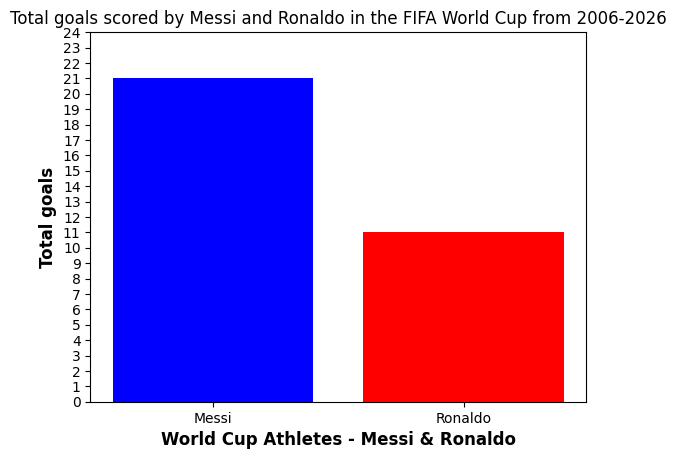

In [ ]:
import matplotlib.pyplot as plt
# Bar plot: Comparing total goals scored by Messi and Ronaldo in the World Cup from 2006 to 2022
athletes = WorldCup_df_updated["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df_updated[WorldCup_df_updated["family_name"].isin(athletes)]
bars = filtered_data.groupby("family_name")["total_goals"].sum()
plt.bar(bars.index, bars, color = ["blue", "red"])
plt.xlabel("World Cup Athletes - Messi & Ronaldo", fontsize = "large", fontweight = "bold")
plt.ylabel("Total goals", fontsize = "large", fontweight = "bold")
plt.title("Total goals scored by Messi and Ronaldo in the FIFA World Cup from 2006-2026")
plt.yticks(np.arange(0, 25, 1))
plt.show()

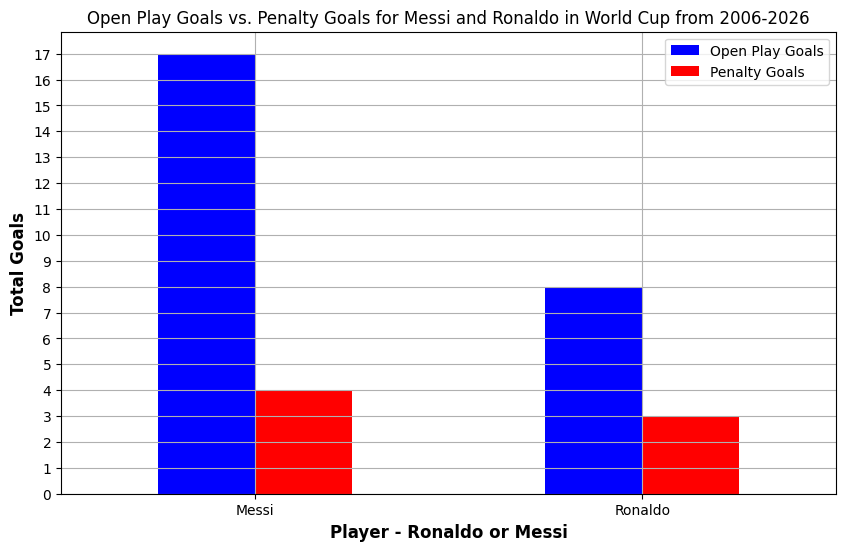

In [ ]:
# Bar plot: Comparing total Open play goals and penalty goals for Messi and Ronaldo

athletes = WorldCup_df_updated["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df_updated[WorldCup_df_updated["family_name"].isin(athletes)]
goaltypes_df = filtered_data.groupby("family_name")[["open_play_goals", "penalty_goals"]].sum()

goaltypes_df.plot(kind="bar", figsize=(10, 6), color = ["blue", "red"])
plt.title("Open Play Goals vs. Penalty Goals for Messi and Ronaldo in World Cup from 2006-2026")
plt.xlabel("Player - Ronaldo or Messi", fontsize = "large", fontweight = "bold")
plt.ylabel("Total Goals",  fontsize = "large", fontweight = "bold")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 18, 1))
plt.grid()
plt.legend(["Open Play Goals", "Penalty Goals"])
plt.show()

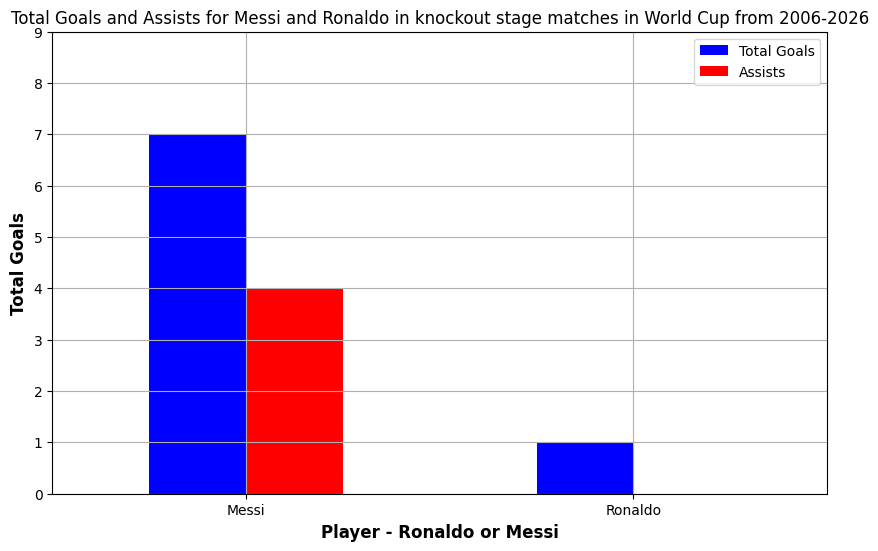

In [ ]:
# Comparing total goals and assists in knockout stage matches

athletes = WorldCup_df_updated["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df_updated[WorldCup_df_updated["family_name"].isin(athletes)]
goaltypes_df = filtered_data[filtered_data["is_knockout"] == "Yes"].groupby("family_name")[["total_goals", "assists"]].sum()

goaltypes_df.plot(kind="bar", figsize=(10, 6), color = ["blue", "red"])
plt.title("Total Goals and Assists for Messi and Ronaldo in knockout stage matches in World Cup from 2006-2026")
plt.xlabel("Player - Ronaldo or Messi", fontsize = "large", fontweight = "bold")
plt.ylabel("Total Goals", fontsize = "large", fontweight = "bold")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, 10, 1))
plt.grid()
plt.legend(["Total Goals", "Assists"])
plt.show()

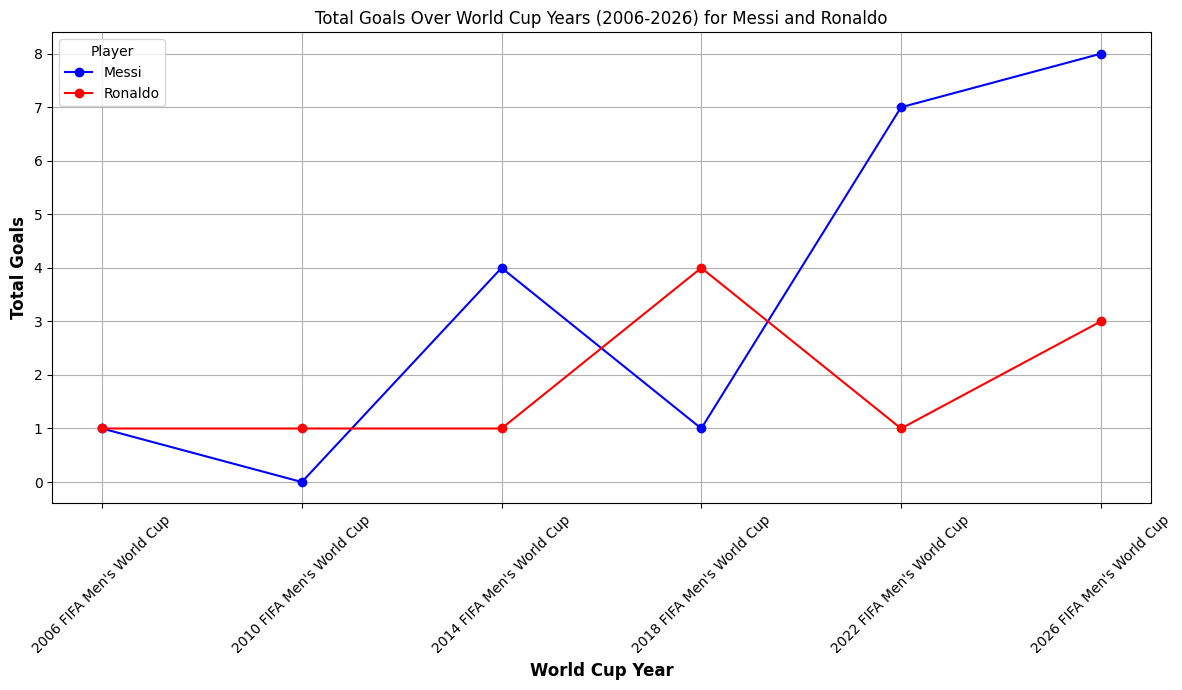

In [ ]:
# Line plot: Comparing how total goals have increased over the years for Messi and Ronaldo

athletes = WorldCup_df_updated["family_name"].value_counts().nlargest(2).index
filtered_data = WorldCup_df_updated[WorldCup_df_updated["family_name"].isin(athletes)]

goalsover_WorldCup = filtered_data.groupby(['tournament_name', 'family_name'])['total_goals'].sum().unstack()

goalsover_WorldCup.plot(kind="line", marker="o", figsize=(12, 7), color = ["blue", "red"])

plt.title("Total Goals Over World Cup Years (2006-2026) for Messi and Ronaldo")
plt.xlabel("World Cup Year", fontsize = "large", fontweight = "bold")
plt.ylabel("Total Goals", fontsize = "large", fontweight = "bold")
plt.xticks(rotation=45)
plt.legend(title="Player")
plt.grid()
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

**3. Hypothesis Testing**

**Research Question: Between Messi and Ronaldo in the 6 World Cups that they’ve both competed in, is there a difference in player performance in knockout stage rounds?**

***Performance is measured by total amount of goals and assists***

**Null Hypothesis:** messi_knockout_data = ronaldo_knockout_data

**Alternative Hypothesis:** messi_knockout_data ≠ ronaldo_knockout_data


In [ ]:
# Filtering data so that it only gets knockout data
# Using groupby function to get Messi and Ronaldo's individual data from knockout stages
knockout_data = WorldCup_df_updated[WorldCup_df_updated['is_knockout'] == 'Yes']

messi_knockout_data = knockout_data[knockout_data['family_name'] == 'Messi'][['total_goals', 'assists']]
ronaldo_knockout_data = knockout_data[knockout_data['family_name'] == 'Ronaldo'][['total_goals', 'assists']]

messi_knockout_data['total_contributions'] = messi_knockout_data['total_goals'] + messi_knockout_data['assists']
ronaldo_knockout_data['total_contributions'] = ronaldo_knockout_data['total_goals'] + ronaldo_knockout_data['assists']

t_stat, p_val = stats.ttest_ind(messi_knockout_data['total_contributions'], ronaldo_knockout_data['total_contributions'])

print(f"Combined T-statistic (Goals + Assists): {t_stat}")
print(f"Combined p-value (Goals + Assists): {p_val}")

if p_val < 0.05:
  print("There is a statistically significant difference between the two group means.")
else:
  print("There is not a statistically significant difference between thw two group means and the null hypothesis can't be rejected.")

Combined T-statistic (Goals + Assists): 2.0902096013287323
Combined p-value (Goals + Assists): 0.04692863198091756
There is a statistically significant difference between the two group means.


**4. Creating a Visualization for Hypothesis Test Results**

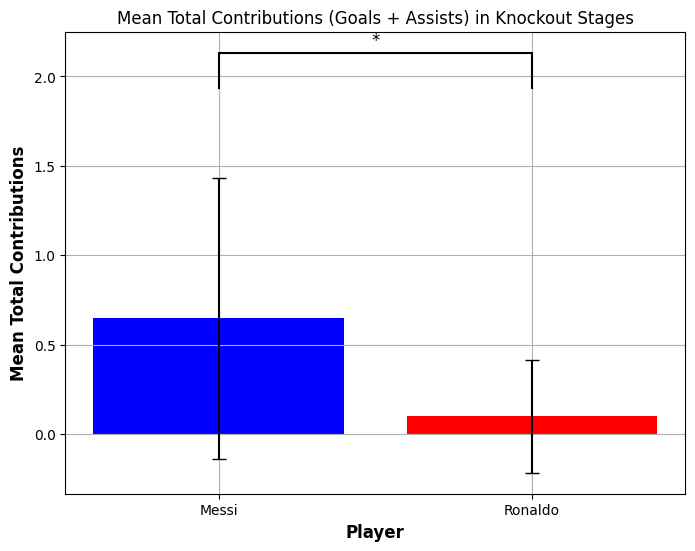

In [ ]:
mean_messi = messi_knockout_data['total_contributions'].mean()
mean_ronaldo = ronaldo_knockout_data['total_contributions'].mean()
means = [mean_messi, mean_ronaldo]

std_messi = messi_knockout_data['total_contributions'].std()
std_ronaldo = ronaldo_knockout_data['total_contributions'].std()
sds = [std_messi, std_ronaldo]

x = ['Messi', 'Ronaldo']

plt.figure(figsize=(8, 6))
plt.bar(x, means, yerr=sds, capsize=5, color=['blue', 'red'])

# Adjust y for annotation based on the data
# This finds the maximum height reached by any bar, including its error bar.
max_y_val = max(mean + std for mean, std in zip(means, sds))
# Then, a small offset is added to place the annotation slightly above this highest point.
y_annotation_pos = max_y_val + 0.5

# Significance annotation
plt.plot([0, 0, 1, 1], [y_annotation_pos, y_annotation_pos + 0.2, y_annotation_pos + 0.2, y_annotation_pos], lw=1.5, c='black')
plt.text(0.5, y_annotation_pos + 0.22, "*", ha="center", va="bottom", color='black', fontsize=12)

plt.title("Mean Total Contributions (Goals + Assists) in Knockout Stages")
plt.xlabel("Player", fontsize = "large", fontweight = "bold")
plt.ylabel("Mean Total Contributions", fontsize = "large", fontweight = "bold")
plt.grid()
plt.show()